<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/geospatial/HW_4/Practical_Dimensionality_Reduction_1077167.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:green">Prof. Glen Nwaila and Dr. Steven Zhang
</span>

# <span style="color:blue">Practical: Dimensionality Reduction
</span>

### PCA
#### In this lesson, we will look at how to do PCA
The dataset used in this lesson comes from the Landsat-8 Optical Land Imager (OLI). It is freely available publically. This is obviously an advantage of satellite-based remote sensing data. Other satellites are also in operation, like the Sentinel satelite, which has higher spatial resolution than the Landsat-8. Although there are advantages and disadvantages to each source.


In [ ]:

import numpy as np
import pandas as pd
import geopandas as gpd

import seaborn as sns                                     # density plots
import matplotlib.pyplot as plt                           # general plotting
import matplotlib as mpl
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

#### Let's load some remote sensing data
This data was acquired on the 30th of December, 2021. The particular image that we are using is a multispectral image over the Assen mine area, which contains a surficial footprint of the Assen iron ore deposit, which is a BIF-type of deposit.

The data has already been pre-processed - here we'll use the tabular format that has been processed.

We won't cover remote sensing data processing in this lecture - that's beyond the scope and strictly within remote sensing as a discipline.

In [ ]:
input_data = pd.read_csv('Processed_Assen_RS_data.csv')

size = (172, 284)

In [ ]:
input_data

,Unnamed: 0,Longitude,Latitude,Band1,Band2,Band3,Band4,Band5,Band6,Band7
0,0,27.564250,-25.105965,188,227,363,406,750,709,440
1,1,27.564548,-25.105963,126,144,215,166,917,479,232
2,2,27.564845,-25.105962,141,187,421,310,2263,947,438
3,3,27.565143,-25.105961,111,170,402,291,2558,1154,562
4,4,27.565440,-25.105960,232,365,658,779,2409,2199,1319
...,...,...,...,...,...,...,...,...,...,...
48843,48843,27.647507,-25.151951,381,449,677,884,1931,2451,1749
48844,48844,27.647804,-25.151950,408,483,720,996,1840,2544,2068
48845,48845,27.648102,-25.151949,364,414,584,796,1464,2274,2039
48846,48846,27.648399,-25.151947,387,415,565,745,1389,2199,1867


In [ ]:
len(input_data)/284


172.0

#### Setup remote sensing data normalisation scales

In [ ]:
%pip install geemap


In [ ]:

import geemap


In [ ]:
Map=geemap.Map()
Map.setCenter(27.597720, -25.125509, 14)

Map

In [ ]:
roi = Map.user_roi
roi.getInfo()

#### Let's look at some maps at middle orebody: -25.125509,27.597720
1. Satellite image
![satellite_500m.png](attachment:satellite_500m.png)

2. Topographic image at zoom 14 = 500 m or 2000 ft

![topography_500m.png](attachment:topography_500m.png)

#### Convert landsat image coordinates to lat and long

#### Process some bands

##### Locality map of Assen Iron Ore Mine
![Satellite%20image%20%281%29%20%20-%20%20Read-Only.png](attachment:Satellite%20image%20%281%29%20%20-%20%20Read-Only.png)

|Orebody |Lat	|Long
| --- | --- | --- |
|Middle orebody|	-25.125509°	| 27.597720°
|West orebody|	-25.127248°	| 27.590647°
|East orebody|	-25.124558°	| 27.607325°

#### Check for missing pixels in bands

In [ ]:
input_data.isnull().values.any()

False

#### Basic data pre-processing to further process the tabular data, as well as to extract metadata

In [ ]:
# We'll need some lists of similar types of metadata to make referencing the data easier
coord_names = ['Longitude', 'Latitude']
bands = ['Band1', 'Band2','Band3', 'Band4', 'Band5', 'Band6', 'Band7']


input_data['Latitude'] = pd.to_numeric(input_data['Latitude'], errors='coerce') #convert latitude to numeric values
input_data['Longitude'] = pd.to_numeric(input_data['Longitude'], errors='coerce') #convert longitude to numeric values



for band in bands:
    input_data[band] = np.abs(pd.to_numeric(input_data[band], errors='coerce')) #make all chemical composition to be numeric


input_data.describe() #print cleaned combined df

,Unnamed: 0,Longitude,Latitude,Band1,Band2,Band3,Band4,Band5,Band6,Band7
count,48848.000000,48848.000000,48848.000000,48848.000000,48848.000000,48848.000000,48848.000000,48848.000000,48848.000000,48848.000000
mean,24423.500000,27.606466,-25.128960,251.722547,316.526327,509.547433,609.615419,1648.147539,1801.414490,1216.814609
std,14101.347312,0.024398,0.013452,94.493587,106.311331,145.656643,238.682890,446.999961,469.584012,432.462650
min,0.000000,27.564250,-25.152291,0.000000,62.000000,149.000000,121.000000,150.000000,141.000000,102.000000
25%,12211.750000,27.585356,-25.140607,186.000000,248.000000,436.000000,467.000000,1382.000000,1539.000000,937.750000
50%,24423.500000,27.606466,-25.128958,245.000000,312.000000,498.000000,577.000000,1585.000000,1830.000000,1196.000000
75%,36635.250000,27.627580,-25.117309,312.000000,377.000000,562.000000,706.000000,1865.000000,2070.000000,1454.000000
max,48847.000000,27.648697,-25.105620,968.000000,1171.000000,1834.000000,2558.000000,5025.000000,4031.000000,3158.000000


#### Basic Exploratory Data Analysis
Note that this is always a part of a data-driven workflow, almost regardless of the type of data and task begin accomplished.

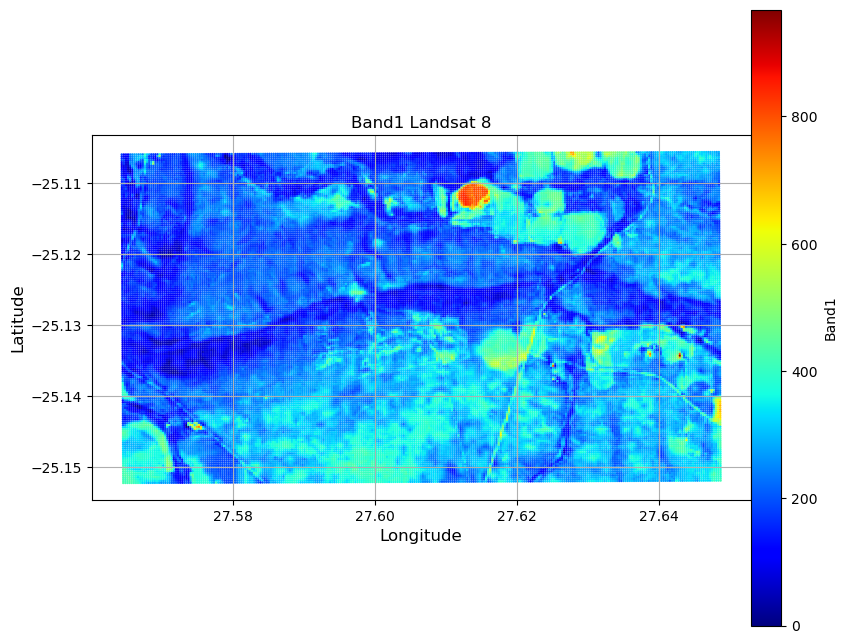

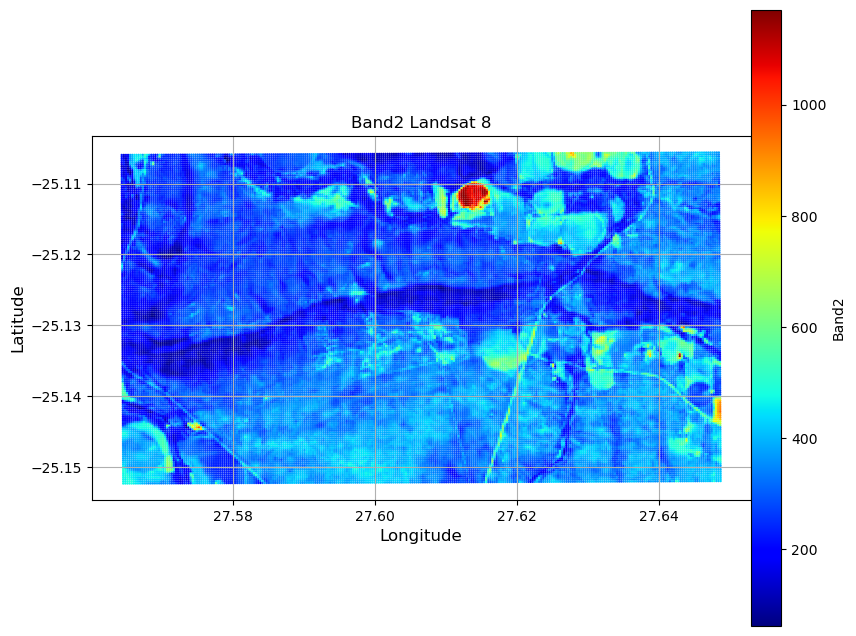

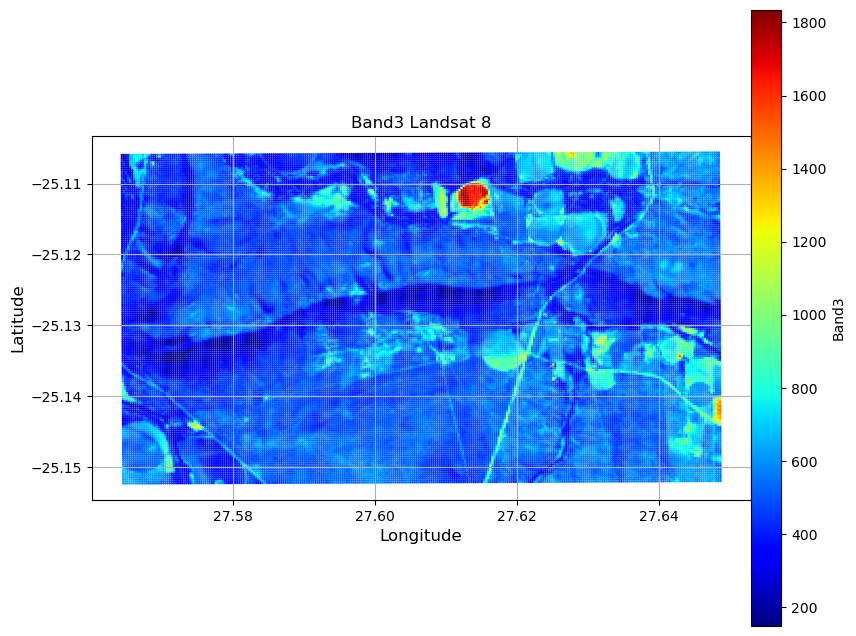

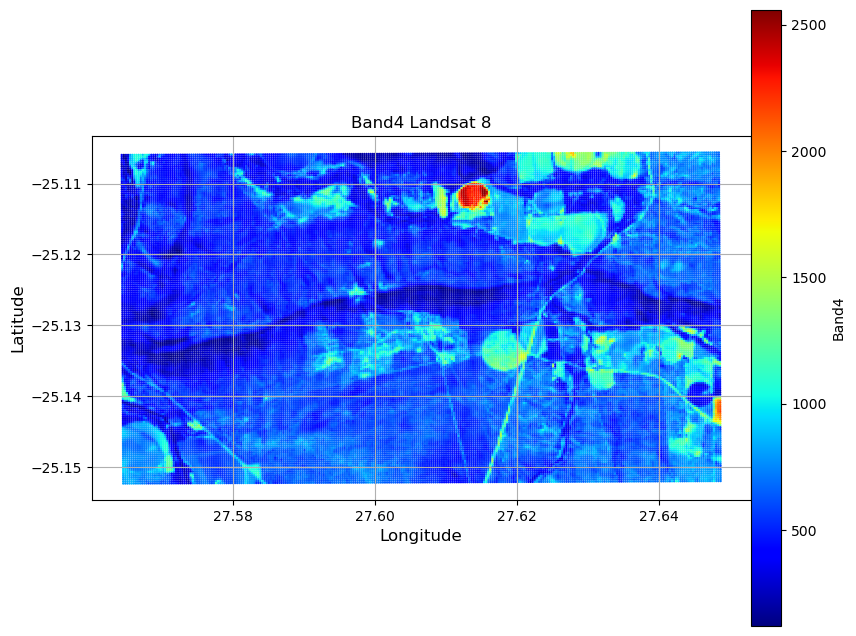

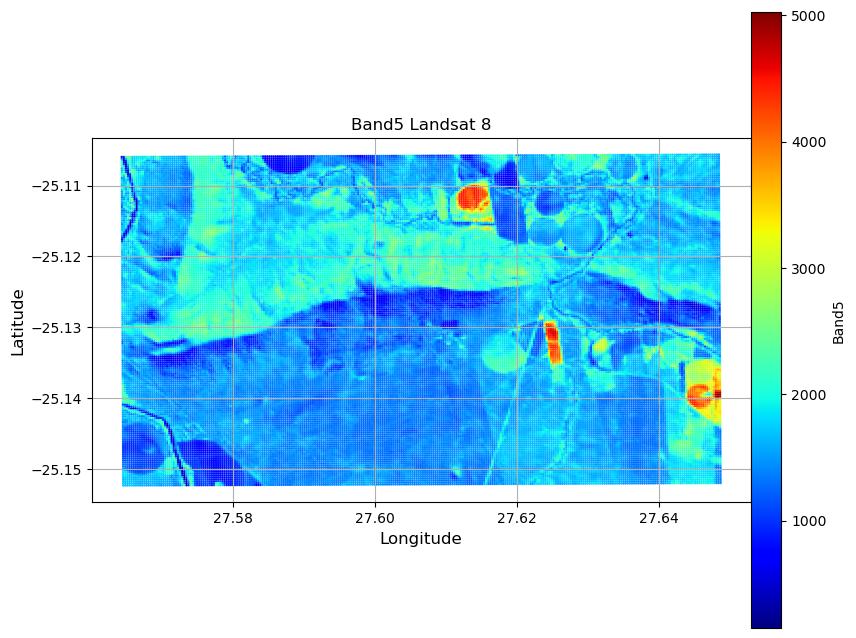

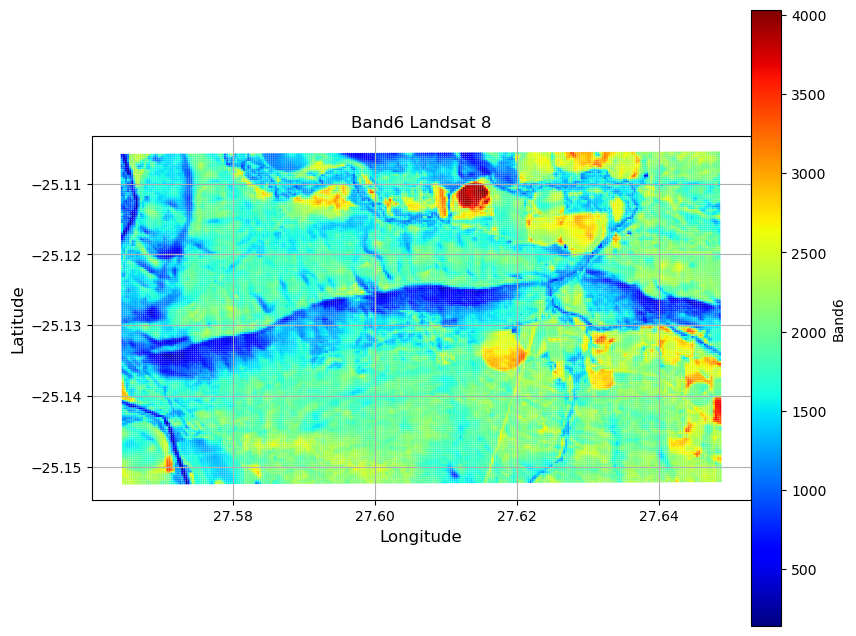

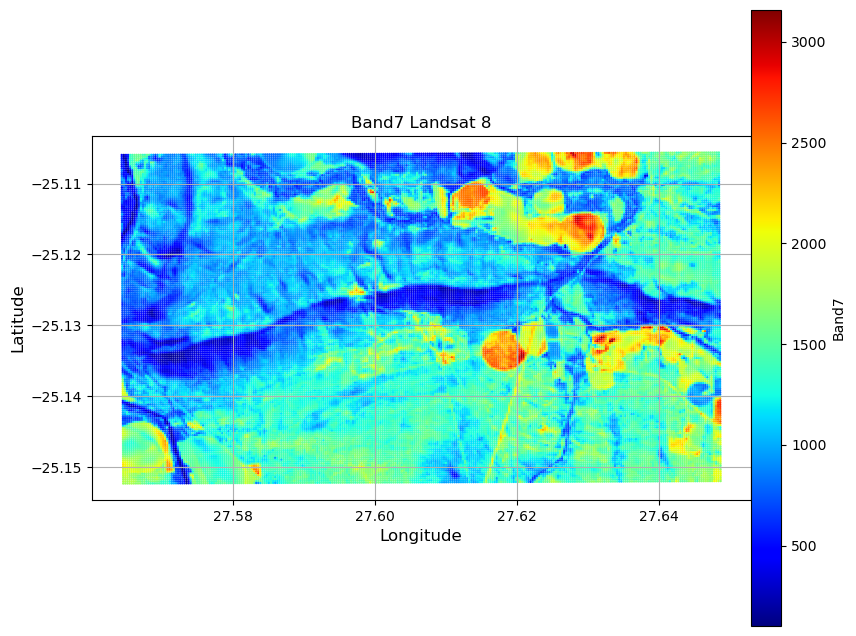

Wall time: 2.67 s


In [ ]:
%%time
for Band in bands:

        fig = plt.figure(figsize = (10,8))
        ax = fig.add_subplot(111)

        ax.set_aspect('equal')
        ax.set_xlabel('Longitude', fontsize = 12)
        ax.set_ylabel('Latitude', fontsize = 12)
        ax.set_title(Band+' Landsat 8', fontsize = 12)

        colormap=plt.cm.get_cmap('jet',int((max(input_data[Band])-min(input_data[Band]))*20))




        scatter=ax.scatter(input_data.Longitude, input_data.Latitude, c = input_data[Band],
                           cmap = colormap, s=3,alpha=1.0, edgecolors='none', label='Landsat 8')

        #ax.text(27.597720,-25.125509,  'M', fontsize=10,color='purple',
                #bbox=dict(facecolor='white', alpha = 0.5, edgecolor='white', boxstyle='round'))

       # ax.text(27.590647,-25.127248,  'W', fontsize=10,color='purple',
                #bbox=dict(facecolor='white', alpha = 0.5, edgecolor='white', boxstyle='round'))

        #ax.text(27.607325,-25.124558,  'E', fontsize=10,color='purple',
                #bbox=dict(facecolor='white', alpha = 0.5, edgecolor='white', boxstyle='round'))

        #ax.text(27.60,-25.13,  'Main Orebody', fontsize=10,color='purple',
                #bbox=dict(facecolor='white', alpha = 0.5, edgecolor='white', boxstyle='round'))



        cbar=fig.colorbar(scatter, pad=-0.000)

        cbar.set_label(Band)
        ax.grid(True)
        plt.show()


#### Binary Scatter Diagrams
We see a lot of linear correlations between bands. This is typical of remote sensing data, because adjacent bands are essentially cut from a spectrum and responses under typical physical conditions are wide-spectrum for many materials. So we expect that differences in the bands are likely subtle relative to the overall band ratios. This hints at why it is important in this discipline to pre-process data to standardize band amplitudes prior to band composition - e.g., for band ratio analysis.

<Figure size 600x600 with 0 Axes>

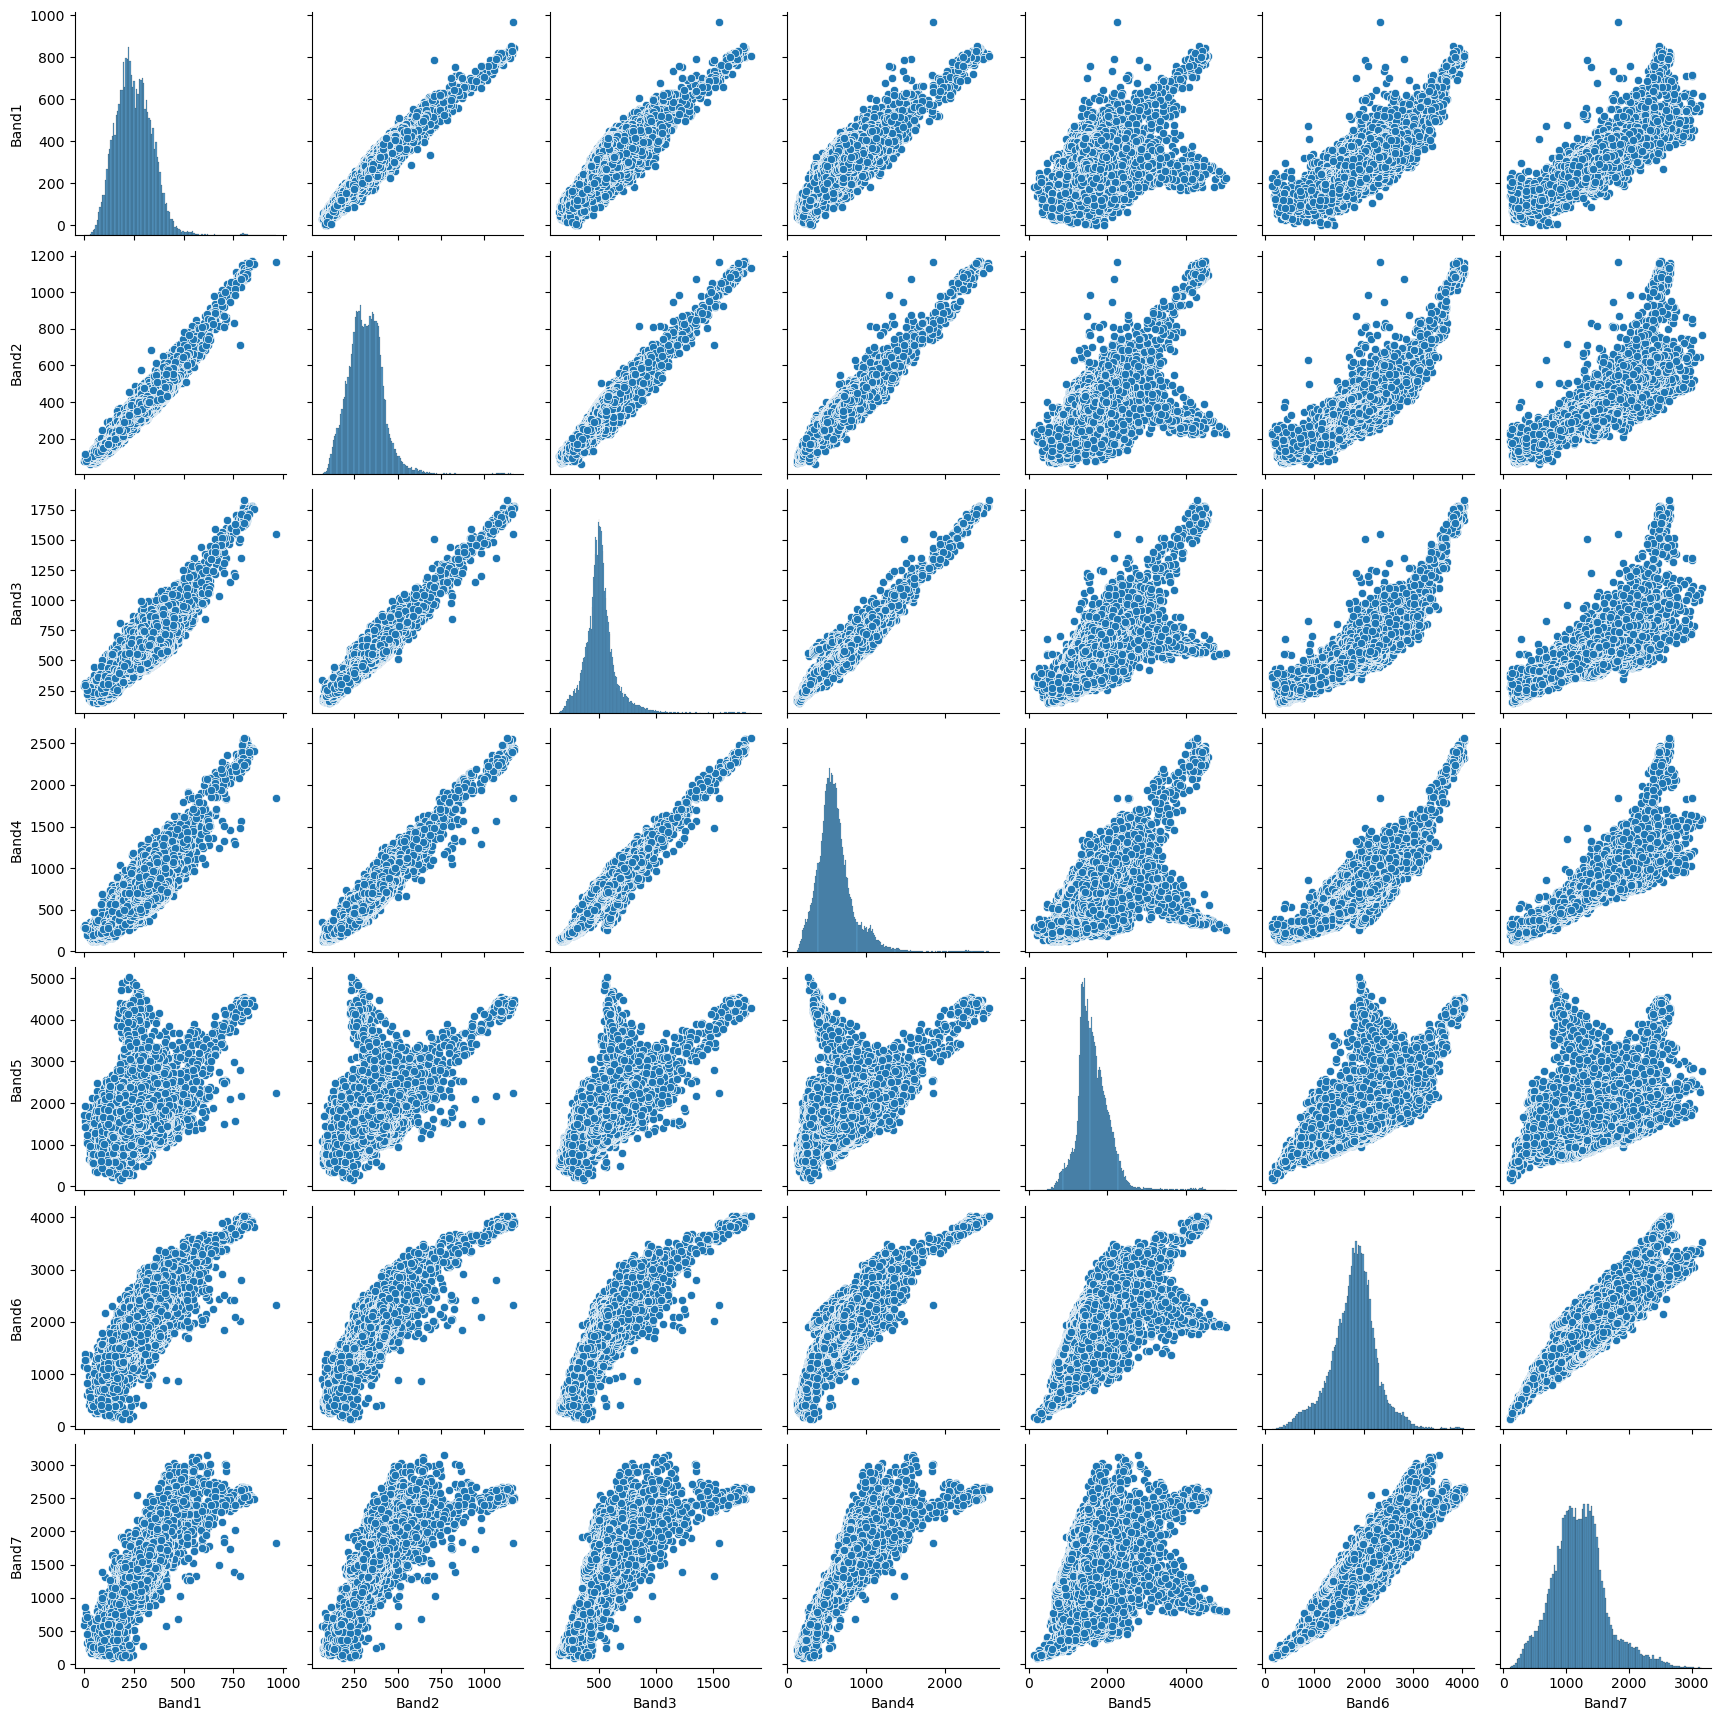

Wall time: 8.14 s


In [ ]:
%%time

plt.figure(figsize = (6,6))
plt.tight_layout()

sns.pairplot(input_data[bands])
plt.show()

In [ ]:
input_data[bands].corr()

,Band1,Band2,Band3,Band4,Band5,Band6,Band7
Band1,1.000000,0.961680,0.838542,0.859693,0.209024,0.843009,0.902813
Band2,0.961680,1.000000,0.934139,0.940130,0.325230,0.890125,0.900225
Band3,0.838542,0.934139,1.000000,0.958334,0.551828,0.881394,0.835769
Band4,0.859693,0.940130,0.958334,1.000000,0.367931,0.867611,0.903213
Band5,0.209024,0.325230,0.551828,0.367931,1.000000,0.502860,0.226579
Band6,0.843009,0.890125,0.881394,0.867611,0.502860,1.000000,0.904205
Band7,0.902813,0.900225,0.835769,0.903213,0.226579,0.904205,1.000000


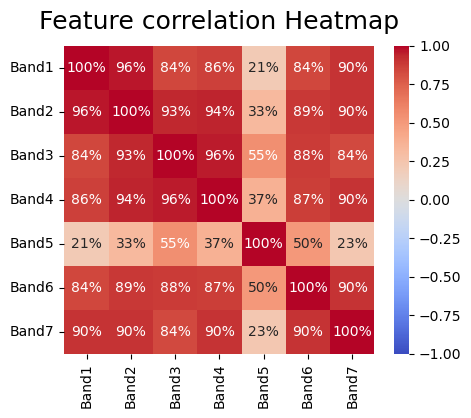

Wall time: 425 ms


In [ ]:
%%time
ax = plt.figure(figsize=(5, 4))


heatmap = sns.heatmap(input_data[bands].corr(), vmin=-1, vmax=1, annot=True, fmt ='.0%', cmap='coolwarm')




heatmap.set_title('Feature correlation Heatmap', fontdict={'fontsize':18}, pad=12);


plt.show()

#### Let's see what traditional band ratios tells us about distribution of minerals in the area
These band ratios are typical of how remote sensing data is analyzed manually. They work because photon interactions with materials are differential over some regions of the spectrum. By enhancing specific differences across the spectrum, it is possible to brine into relief, target minerals of interest.

In [ ]:
r = input_data['Band4']
g = input_data['Band3']
b = input_data['Band2']
B1 = input_data['Band1']
nir = input_data['Band5']
SWIR1 = input_data['Band6']
SWIR2 = input_data['Band7']


ferrous_minerals_ratio = (SWIR1/nir).values.reshape((172, 284))#High values in band ratio 4/2 are useful to detect the charge transfer absorption related to ferric iron oxides
ferric_iron_oxide = ((r+SWIR1)/nir).values.reshape((172, 284)) # are useful to detect the crystal-field absorption of ferric iron oxide
clay_minerals_ratio = (SWIR1/SWIR2).values.reshape((172, 284))



#False color Composite (FCC) 753
ndvi = (nir.astype(float)-r.astype(float))/(nir+r) #Normalized Difference Vegetation Index (NDVI)
ndvi = ndvi.values.reshape((172, 284))
ndwi = (nir.astype(float)-g.astype(float))/(nir+g) #Normalized Difference Water Index (NDWI)
ndwi = ndwi.values.reshape((172, 284))
B42  = r/b
B42.values.reshape((172, 284))
B57  = nir/SWIR1 # this should be nir/SWIR2
B57.values.reshape((172, 284))
B54 = nir/r
B54.values.reshape((172, 284))
#Landsat 8 image ratios (4/2, 5/7, 5/4) in RGB recognized the distribution of iron ore (red-yellow color range)


#543 distinguish vegitation
#764 urban area
#Bathymetric (4, 3, 1)
#Geology (7, 6, 2)
#Agriculture (6, 5, 2)
#Short-Wave Infrared (7, 6 4)
#Color Infrared (5, 4, 3)
#Natural Color (4, 3, 2)




'''B1 = "Band 1",
   B2 = "Blue",
   B3 = "Green",
   B4 = "Red",
   B5 = "NIR",
   B6 = "SWIR1",
   B7 = "SWIR2"]

'''


'B1 = "Band 1", \n   B2 = "Blue", \n   B3 = "Green", \n   B4 = "Red",\n   B5 = "NIR", \n   B6 = "SWIR1", \n   B7 = "SWIR2"]\n\n'

Let's have a look at the ferrous minerals in the area. It seems like the bottom half of the image is full of such minerals.

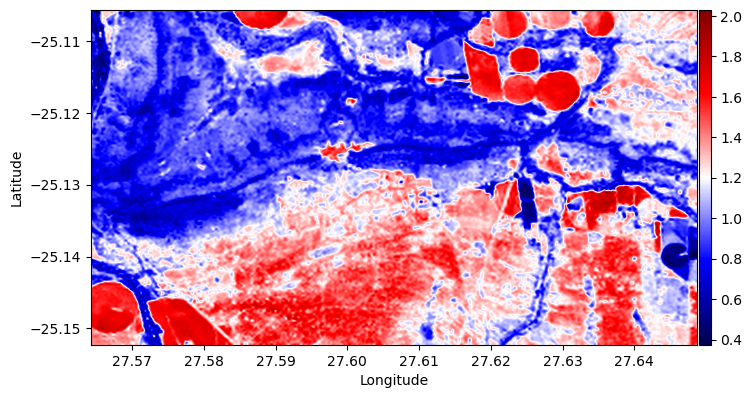

In [ ]:
xmin = input_data['Longitude'].min()
xmax = input_data['Longitude'].max()
ymin = input_data['Latitude'].min()
ymax = input_data['Latitude'].max()

vmin = np.min(ferrous_minerals_ratio)
vmax = np.max(ferrous_minerals_ratio)



fig, ax = plt.subplots(1, 1)
fig.set_size_inches(8, 8, forward=True)



im =ax.imshow(ferrous_minerals_ratio, cmap="seismic", vmin=vmin, vmax =vmax,
               extent = [xmin,xmax, ymin,ymax], aspect=1, interpolation = 'lanczos')

plt.xlabel('Longitude')
plt.ylabel('Latitude')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.02)
cbar = plt.colorbar(im, cax=cax)

plt.show()

Similarly, the ferric map shows that the bottom half is enriched. This probably means that iron concentrations are generally higher there.

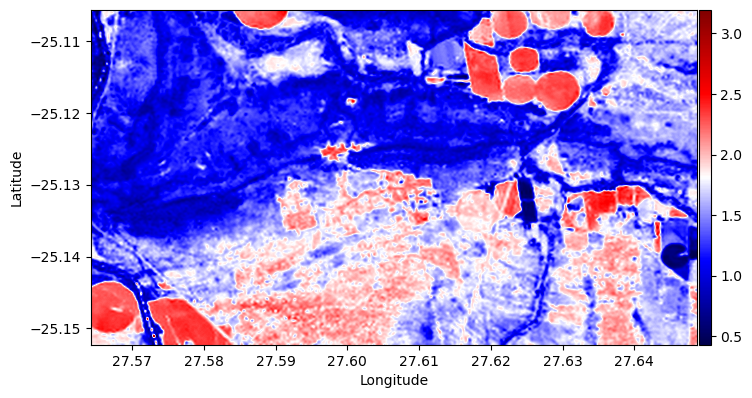

In [ ]:
vmin = np.min(ferric_iron_oxide)
vmax = np.max(ferric_iron_oxide)


fig, ax = plt.subplots(1, 1)
fig.set_size_inches(8, 8, forward=True)

im =ax.imshow(ferric_iron_oxide, cmap="seismic", vmin=vmin, vmax =vmax,
               extent = [xmin,xmax, ymin,ymax], aspect=1, interpolation = 'lanczos')

plt.xlabel('Longitude')
plt.ylabel('Latitude')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.02)
cbar = plt.colorbar(im, cax=cax)

plt.show()

The clay minerals seem to be mutually exclusive with the iron-rich groundmass. The top of the map is full of clay.

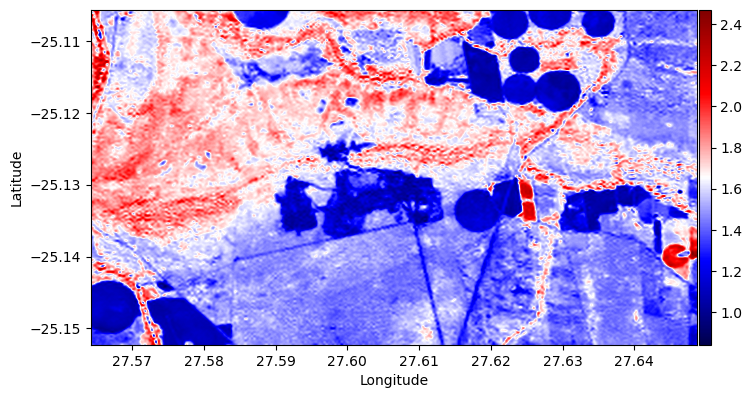

In [ ]:
vmin = np.min(clay_minerals_ratio)
vmax = np.max(clay_minerals_ratio)


fig, ax = plt.subplots(1, 1)
fig.set_size_inches(8, 8, forward=True)

im =ax.imshow(clay_minerals_ratio, cmap="seismic", vmin=vmin, vmax =vmax,
               extent = [xmin,xmax, ymin,ymax], aspect=1, interpolation = 'lanczos')

plt.xlabel('Longitude')
plt.ylabel('Latitude')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.02)
cbar = plt.colorbar(im, cax=cax)

plt.show()

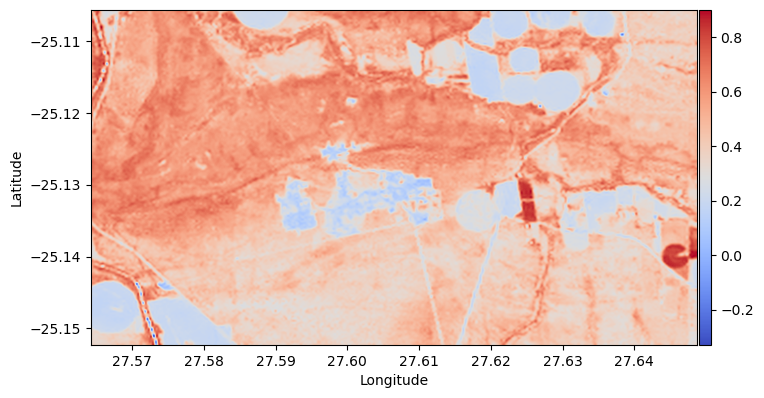

In [ ]:
vmin = np.min(ndvi)
vmax = np.max(ndvi)


fig, ax = plt.subplots(1, 1)
fig.set_size_inches(8, 8, forward=True)

im =ax.imshow(ndvi, cmap="coolwarm", vmin=vmin, vmax =vmax,
               extent = [xmin,xmax, ymin,ymax], aspect=1, interpolation = 'lanczos')

plt.xlabel('Longitude')
plt.ylabel('Latitude')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.02)
cbar = plt.colorbar(im, cax=cax)

plt.show()

#### Let's see if we can do some basic image segmentation using dimensionality reduction
First let's build the basic input data of features.

In [ ]:

features = input_data[bands].copy()

for name in bands:
    features[name] = pd.to_numeric(features[name], errors='coerce')

features.fillna(0, inplace=True)

features.head(10)

,Band1,Band2,Band3,Band4,Band5,Band6,Band7
0,188,227,363,406,750,709,440
1,126,144,215,166,917,479,232
2,141,187,421,310,2263,947,438
3,111,170,402,291,2558,1154,562
4,232,365,658,779,2409,2199,1319
5,257,395,675,927,1785,2221,1413
6,278,445,735,1015,1865,2363,1528
7,284,448,742,1043,1817,2382,1576
8,259,428,726,997,1835,2347,1555
9,285,464,755,1052,1892,2409,1536


#### ML-specific data pre-processing


In [ ]:
%%time

scaler = MinMaxScaler()

features_scaled = scaler.fit_transform(features[bands])

features_scaled = pd.DataFrame(features_scaled,columns=features[bands].columns, index=features.index)
features_scaled

Wall time: 18.5 ms


,Band1,Band2,Band3,Band4,Band5,Band6,Band7
0,0.194215,0.148783,0.127003,0.116947,0.123077,0.146015,0.110602
1,0.130165,0.073940,0.039169,0.018465,0.157333,0.086889,0.042539
2,0.145661,0.112714,0.161424,0.077554,0.433436,0.207198,0.109948
3,0.114669,0.097385,0.150148,0.069758,0.493949,0.260411,0.150524
4,0.239669,0.273219,0.302077,0.270004,0.463385,0.529049,0.398233
...,...,...,...,...,...,...,...
48843,0.393595,0.348963,0.313353,0.313090,0.365333,0.593830,0.538940
48844,0.421488,0.379621,0.338872,0.359048,0.346667,0.617738,0.643325
48845,0.376033,0.317403,0.258160,0.276980,0.269538,0.548329,0.633835
48846,0.399793,0.318305,0.246884,0.256053,0.254154,0.529049,0.577552


#### Let's try some PCA on this dataset.
PCA is principal component analysis. It recoordinates the scatter cloud in directions of decreasing variability. Basically, it creates linear combinations of existing coordinates such that each combination captures some significant variability of the data cloud. It is very useful for dimensional reduction where the data is substantially linearly reducible. Outside of ML, PCA has been used for a long time in multivariate statistical analysis on different types of geoscientific data (e.g., geochemical data for exploration). However, when used in that manner, the PCA does not constitute an application of ML. Let's try using it for dimensional reduction here, because we observed earlier that the dataset has a lot of linear correlations between bands. We might be able to get the same image segmentation using less features through PCA.
![image.png](attachment:image.png)


Image taken from https://medium.com/@raghavan99o/principal-component-analysis-pca-explained-and-implemented-eeab7cb73b72

![Picture1-2.gif](attachment:Picture1-2.gif)

Mueller, V. (2021). Eigenvalues and eigenvectors: What do they tell us about our data? Accessed at https://towardsdatascience.com/eigenvalues-and-eigenvectors-378e851bf372 on the 21 September 2021.


Let's quickly discuss what PCA has been used for and what it has been found to be useful for.


In [ ]:
# Let's recall what our data looked like

X = features_scaled
X

,Band1,Band2,Band3,Band4,Band5,Band6,Band7
0,0.194215,0.148783,0.127003,0.116947,0.123077,0.146015,0.110602
1,0.130165,0.073940,0.039169,0.018465,0.157333,0.086889,0.042539
2,0.145661,0.112714,0.161424,0.077554,0.433436,0.207198,0.109948
3,0.114669,0.097385,0.150148,0.069758,0.493949,0.260411,0.150524
4,0.239669,0.273219,0.302077,0.270004,0.463385,0.529049,0.398233
...,...,...,...,...,...,...,...
48843,0.393595,0.348963,0.313353,0.313090,0.365333,0.593830,0.538940
48844,0.421488,0.379621,0.338872,0.359048,0.346667,0.617738,0.643325
48845,0.376033,0.317403,0.258160,0.276980,0.269538,0.548329,0.633835
48846,0.399793,0.318305,0.246884,0.256053,0.254154,0.529049,0.577552


In [ ]:
# This is the PCA package from sklearn (others are also possible)
from sklearn.decomposition import PCA


In [ ]:
# As with all sklearn objects, we instantiate a PCA object this way

pca = PCA(n_components=None, svd_solver = 'full') #Here you can change none to 8 which is the total number of elements


In [ ]:
# Then we use the object on the data that we have

x_pca = pca.fit(X)  #You'll remember this syntax from the linear regression example we did before using sklearn


Let's read this together to see what this PCA object has to offer

https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

In [ ]:
# If you read into the PCA documentation on sklearn, you'll see that it has this method to access the explained variance ratios

x_pca.explained_variance_ratio_

array([0.83127504, 0.10996043, 0.02933562, 0.01812405, 0.0090623 ,
       0.0013634 , 0.00087916])

In [ ]:
# That means we can visualize the variance ratios using a scatter plot

# First we'll build the x-axis, which is just the number of components
x = [pc+1 for pc in range(len(x_pca.explained_variance_ratio_))]

# Then we'll build the y-axis, which is that vector of ratios
y = x_pca.explained_variance_ratio_

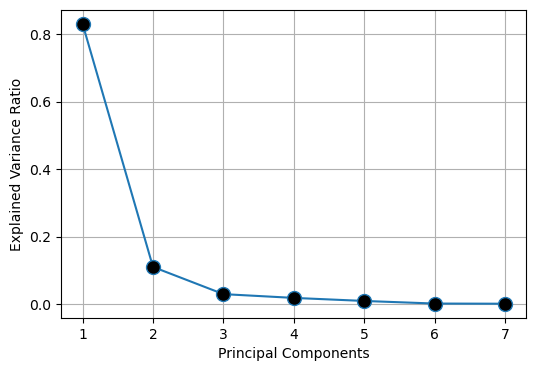

In [ ]:
# Now we can conveniently see what the results look like

plt.figure(figsize=(6,4))
plt.plot(x, y, markersize = 10, marker = 'o', markerfacecolor = 'k')


plt.grid(True)
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")

plt.show()

So our hunch was right, the dataset is highly reducible using PCA. A single principal component contains almost all of the variability in the dataset.

PC 1 seems to be the most significant.

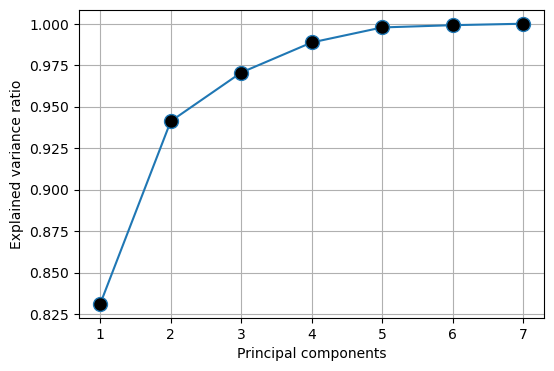

In [ ]:
# Another way to visualize this information is to look at the cumulative sum of the variance ratios
# What this shows is also interesting, let's discuss

plt.figure(figsize = (6,4))
plt.plot(x, y.cumsum(), markersize = 10, marker = 'o', markerfacecolor = 'k')


plt.grid(True)
plt.xlabel("Principal components")
plt.ylabel("Explained variance ratio")

plt.show()

At just 3 principal components, we capture almost 97.5% of the dataset's variability! That means we don't necessarily need that many bands for a lot of ML algorithms and can likely get away with far less. This reduces computational burden and can speed up a lot of workloads. This is actually a very common use of PCA for very large datasets.

Let's discuss what curse of dimensionality is. Read here -
https://en.wikipedia.org/wiki/Curse_of_dimensionality#Machine_learning

In [ ]:
# We can access the PCA components using this - what are these?

x_pca.components_

array([[ 0.35556829,  0.36301808,  0.31895394,  0.36605023,  0.14673302,
         0.45100347,  0.53021691],
       [-0.21781557, -0.07496443,  0.18358021, -0.01090513,  0.89088896,
         0.17297311, -0.29918766],
       [ 0.24526464,  0.38541318,  0.40381368,  0.36751312, -0.04431677,
        -0.51795232, -0.47215672],
       [ 0.65226324,  0.26833559, -0.2191367 , -0.56013488,  0.07848857,
         0.20864554, -0.30180008],
       [ 0.31885847, -0.17048141, -0.10824797, -0.13451528,  0.38362141,
        -0.65558048,  0.51234971],
       [-0.22208348,  0.10199069,  0.70892034, -0.62219238, -0.12891862,
        -0.06442158,  0.17267099],
       [ 0.43535469, -0.77626341,  0.37308797,  0.10887432, -0.11347443,
         0.14468134, -0.15173668]])

In [ ]:
X.columns.values

array(['Band1', 'Band2', 'Band3', 'Band4', 'Band5', 'Band6', 'Band7'],
      dtype=object)

In [ ]:
# Let's analyze the component loadings a bit

loadings = x_pca.components_
num_pc = x_pca.n_features_


pc_list = ["PC"+str(i) for i in list(range(1, num_pc+1))]

loadings_df = pd.DataFrame.from_dict(dict(zip(pc_list, loadings)))

loadings_df['Band'] = X.columns.values

loadings_df = loadings_df.set_index('Band')
loadings_df




,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Band,,,,,,,
Band1,0.355568,-0.217816,0.245265,0.652263,0.318858,-0.222083,0.435355
Band2,0.363018,-0.074964,0.385413,0.268336,-0.170481,0.101991,-0.776263
Band3,0.318954,0.183580,0.403814,-0.219137,-0.108248,0.708920,0.373088
Band4,0.366050,-0.010905,0.367513,-0.560135,-0.134515,-0.622192,0.108874
Band5,0.146733,0.890889,-0.044317,0.078489,0.383621,-0.128919,-0.113474
Band6,0.451003,0.172973,-0.517952,0.208646,-0.655580,-0.064422,0.144681
Band7,0.530217,-0.299188,-0.472157,-0.301800,0.512350,0.172671,-0.151737


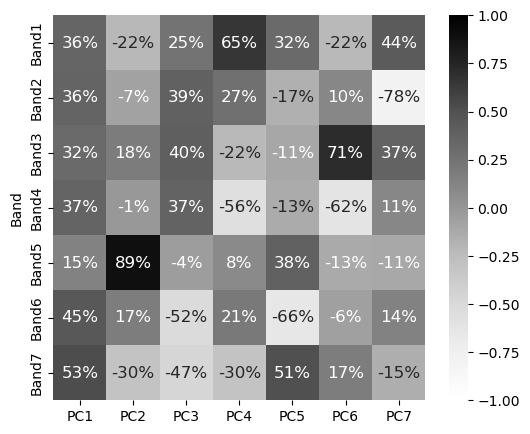

In [ ]:
# One way to visualize this is through a heatmap
# Although different datasets and analysis practices uses different visualizations, biplots are another popular one

plt.figure(figsize = (6, 5))
sns.heatmap(loadings_df, vmin=-1, vmax=1, annot=True, fmt='.0%',cmap='Greys', annot_kws={"size":12})

plt.show()

We actually didn't transform the data yet. We only called the ".fit()" from the PCA object. Now we'll actually transform our dataset using the trained PCA model using the ".transform()" method. If you don't want to analyze the components and so on, you can most of the time in sklearn do fit and transform in one shot, using ".fit_transform()".

In [ ]:
x_trans = pca.transform(X)



x_trans = pd.DataFrame(x_trans, columns = pc_list)




x_trans

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-0.399501,-0.131322,0.160553,0.004921,-0.003382,-0.005334,0.011308
1,-0.571236,-0.086156,0.105579,0.028365,0.028741,-0.012095,-0.004085
2,-0.360513,0.175980,0.089031,0.015418,0.067473,0.006617,0.000455
3,-0.329155,0.232870,0.018701,0.001534,0.071591,0.004570,-0.011518
4,0.148892,0.163295,-0.002673,-0.036316,-0.022835,0.007263,-0.010359
...,...,...,...,...,...,...,...
48843,0.339922,0.007445,-0.010984,0.021159,-0.001677,-0.005246,0.005902
48844,0.449321,-0.040471,-0.025973,-0.011736,0.023693,0.000073,-0.001491
48845,0.307136,-0.117707,-0.080006,-0.012095,0.050636,0.010442,-0.011880
48846,0.263860,-0.124994,-0.048833,0.029594,0.039995,0.003791,-0.001225


We'll also add the coordinates back to the PCA-transformed data to create a dataframe that simplifies visualization.

In [ ]:
pca_data = pd.concat([input_data[coord_names], x_trans], axis = 1)
pca_data

,Longitude,Latitude,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,27.564250,-25.105965,-0.399501,-0.131322,0.160553,0.004921,-0.003382,-0.005334,0.011308
1,27.564548,-25.105963,-0.571236,-0.086156,0.105579,0.028365,0.028741,-0.012095,-0.004085
2,27.564845,-25.105962,-0.360513,0.175980,0.089031,0.015418,0.067473,0.006617,0.000455
3,27.565143,-25.105961,-0.329155,0.232870,0.018701,0.001534,0.071591,0.004570,-0.011518
4,27.565440,-25.105960,0.148892,0.163295,-0.002673,-0.036316,-0.022835,0.007263,-0.010359
...,...,...,...,...,...,...,...,...,...
48843,27.647507,-25.151951,0.339922,0.007445,-0.010984,0.021159,-0.001677,-0.005246,0.005902
48844,27.647804,-25.151950,0.449321,-0.040471,-0.025973,-0.011736,0.023693,0.000073,-0.001491
48845,27.648102,-25.151949,0.307136,-0.117707,-0.080006,-0.012095,0.050636,0.010442,-0.011880
48846,27.648399,-25.151947,0.263860,-0.124994,-0.048833,0.029594,0.039995,0.003791,-0.001225


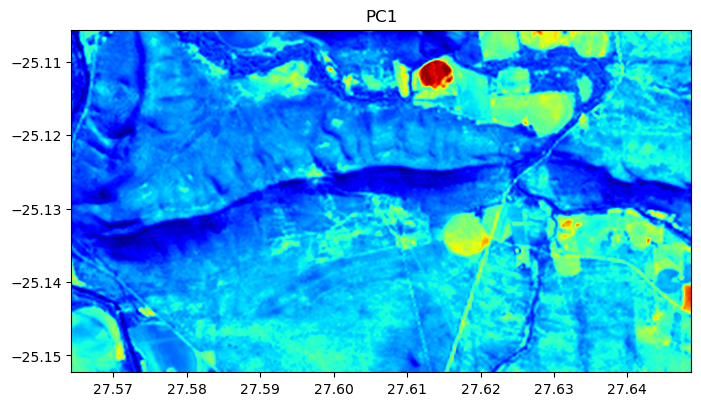

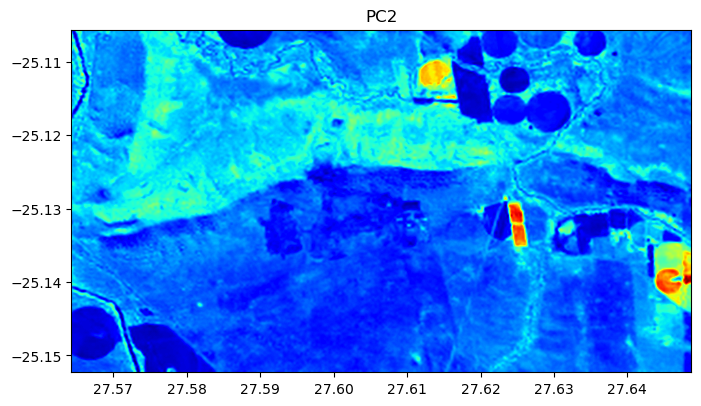

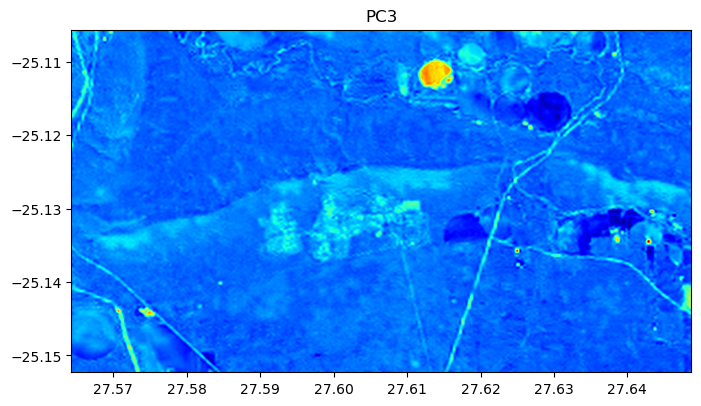

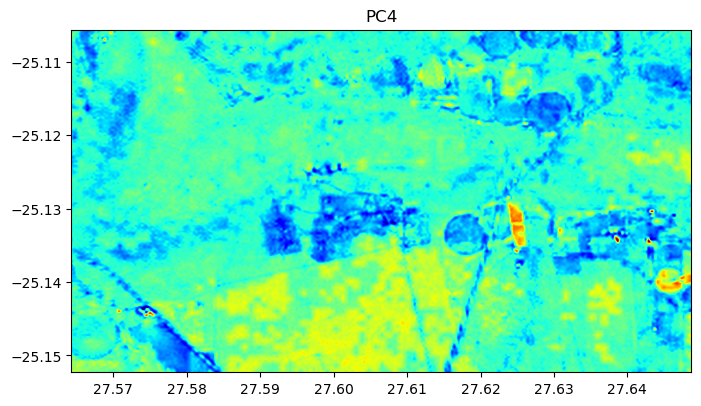

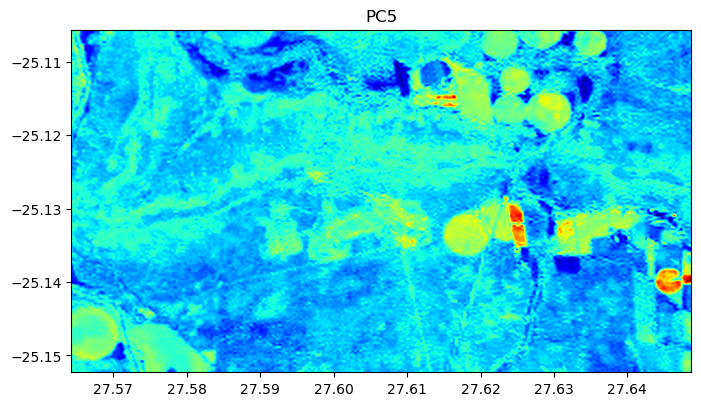

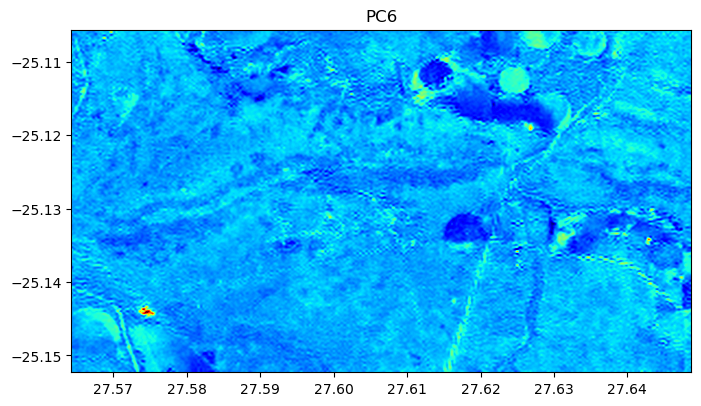

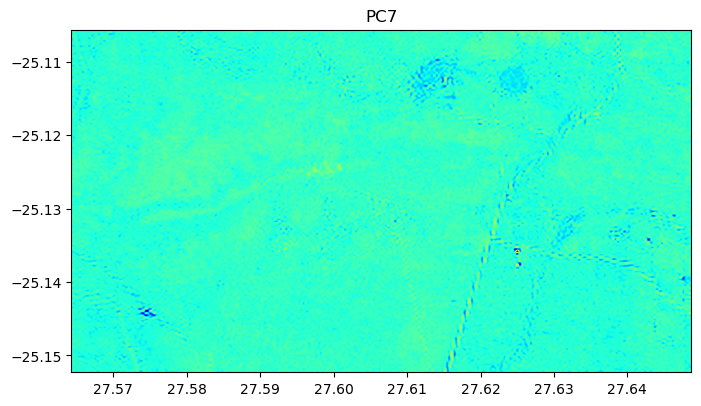

In [ ]:
xmin = input_data['Longitude'].min()
xmax = input_data['Longitude'].max()
ymin = input_data['Latitude'].min()
ymax = input_data['Latitude'].max()

for pc in x_trans.columns:
    map_matrix = pca_data[pc].values.reshape(size)

    vmin = np.min(map_matrix)
    vmax = np.max(map_matrix)


    fig, ax = plt.subplots(1, 1)
    fig.set_size_inches(8, 8)

    im =ax.imshow(map_matrix, cmap="jet",  vmin=vmin, vmax =vmax,
                   extent = [xmin,xmax, ymin,ymax], aspect=1, interpolation = 'lanczos')
    plt.title(pc)
    plt.show()





Notice how in the visualizations, a single PCA basically captured all the anthropogenic footprint in the image? In fact, after about principal component 3, there isn't much in the images. The last two images look like mostly noise. I think we are safe to discard most of the data in lieu of just a few first principal components. Let's try that.

### Assignment

Perform clustering on the original data and compare it with the PCA-reduced data. Use 3 principal components. I recommend you try k-Means clustering. You can pick the number of clusters (k) using the elbow method. You can also use the Yellowbricks package if you wish, which facilitates this.

Visualize the results of the clusters and compare between the results of the clusters of the original data and the PCA-reduced data at the same number of clusters. What do you see? Comment on your results.